In [461]:
import json
import math
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.linear_model import LinearRegression

In [462]:
ORIGINAL_FPS = 30
MANUAL_FPSS = ['3', '5', '6', '10', '15']
USE_MANUAL_FPSS = True
THRESHOLD = 0.75

RP_AMOUNT = 8

In [463]:
accuracy_result_dict_paths = [
	'./short_result/plot_set/Scene-1-Day_Accuracy_Result.json',
	'./short_result/plot_set/Scene-1-Afternoon_Accuracy_Result.json',
	'./short_result/plot_set/Scene-1-Night_Accuracy_Result.json',
	# './short_result/plot_set/Scene-1-Midnight_Accuracy_Result.json',
]

In [464]:
movement_result_dict_paths = [
	'./short_result/plot_set/Scene-1-Day_Movement_Result.json',
	'./short_result/plot_set/Scene-1-Afternoon_Movement_Result.json',
	'./short_result/plot_set/Scene-1-Night_Movement_Result.json',
	# './short_result/plot_set/Scene-1-Midnight_Movement_Result.json',
]

In [465]:
def round_floats_to_sigfigs(input_list, sigfigs):
	return [round(number, sigfigs) for number in input_list]

In [466]:
def load_json(filepath):
	with open(filepath, 'r') as file:
		data = json.load(file)
		
	return data

In [467]:
def extract_fpss(metric_list, data_type='metric'):
	return list(metric_list[list(metric_list.keys())[0]][0][data_type].keys())

In [468]:
def extract_metric_list(metric_list, fpss, feature='F1', data_type='metric'):
	result_column = {}
		
	for fps in fpss:
		if data_type == 'metric':
			result_column[fps] = [clip_metric[data_type][fps][feature] for clip_metric in metric_list]
		elif data_type == 'movement':
			result_column[fps] = [clip_metric[data_type][fps] for clip_metric in metric_list]
		
	return result_column

In [469]:
def cumulative_sum_list(input_list):
	result = []
	total = 0
	for item in input_list:
		total += item
		result.append(total)
	return result

def extract_metric_time(metric_list):
	frame_number_list = [clip_metric['frame_count'] for clip_metric in metric_list]
	time_list = cumulative_sum_list(frame_number_list)
	time_list = list(np.array(time_list) - time_list[0])
	scaled_time_list = list(np.array(time_list) / ORIGINAL_FPS)

	return round_floats_to_sigfigs(scaled_time_list, 0)

In [470]:
colors = [
	'#e6194B',
	'#f58231',
	'#9A6324',
	'#911eb4',
	'#3cb44b',
	'#f032e6',
	'#4363d8',
	'#f7cc1d',
]

In [471]:
def plot_mutiple_lines(xs, yss, x_label, y_label, title, use_MANUAL_FPSS=False, plot_size=(36, 12), label_size=28, font_size=32, legend_size=20):
	fig, ax1 = plt.subplots(figsize=plot_size)
		
	if use_MANUAL_FPSS:
		fpss = MANUAL_FPSS
	else:
		fpss = list(yss.keys())

	for i in range(len(fpss)):
		fps = fpss[i]
		ax1.plot(xs, yss[fps], color=colors[i], marker='o', label=fps + " FPS")

	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y_label, fontsize=font_size)
	ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	plt.legend(fontsize=legend_size)
	plt.grid(True)

	plt.show()

In [472]:
def find_max_index(string_list):
	# Convert each element to integer
	int_list = [int(element) for element in string_list]
		
	# Find index of maximum integer value
	max_index, max_value = max(enumerate(int_list), key=lambda x: x[1])
		
	return max_value

In [473]:
def extract_cheapest_fps(accuracy_dict, fpss, threshold=0.75, use_MANUAL_FPSS=False):
	if use_MANUAL_FPSS:
		fpss = MANUAL_FPSS
	else:
		fpss = fpss
				
	max_fps = find_max_index(fpss)
	
	cheapest_fpss = []
	for i in range(len(accuracy_dict[fpss[0]])):
		curr_fps = max_fps
		for fps in fpss:
			if accuracy_dict[fps][i] >= threshold and int(fps) < int(curr_fps):
				curr_fps = fps
		
		cheapest_fpss.append(int(curr_fps))
	
	return cheapest_fpss

In [474]:
def duplicate_elements_accuracy(input_list):
	result = []
	for item in input_list:
		result.append(item)
		result.append(item)
	return result

In [475]:
def duplicate_elements_time(input_list):
	result = [0]
	for item in input_list:
		if item == input_list[-1]:
			result.append(item)
			break
		result.append(item)
		result.append(item)
	return result

def cumulative_sum_list(input_list):
	result = []
	total = 0
	for item in input_list:
		total += item
		result.append(total)
	return result

def extract_metric_time_horizontal(metric_list):
	frame_number_list = [clip_metric['frame_count'] for clip_metric in metric_list]
	time_list = cumulative_sum_list(frame_number_list)
	time_list = duplicate_elements_time(time_list)
	scaled_time_list = list(np.array(time_list) / ORIGINAL_FPS)

	return round_floats_to_sigfigs(scaled_time_list, 0)

In [476]:
def plot_one_line(xs, ys, x_label, y_label, title, label_size=28, font_size=32, legend_size=20):
	fig, ax1 = plt.subplots(figsize=(9, 9))
	
	ax1.plot(xs, ys, color='black', label="Minimum Required FPS")

	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y_label, fontsize=font_size)
	# ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	plt.legend(fontsize=legend_size)
	plt.grid(True)

	plt.show()

In [477]:
def combine_average(matrix, interval):
		result = []
		new_len = math.floor(len(matrix) / interval)

		i = 0
		while len(result) < new_len:
				result.append(np.average(np.array(matrix[i:i+interval])))
				i += interval
		
		return result

In [478]:
def plot_two_ys(xs, y1s, y2s, x_label, y1_label, y2_label, title, label_size=28, font_size=32):
	fig, ax1 = plt.subplots(figsize=(36, 9))

	ax1.plot(xs, y1s, color=colors[0], marker='o', label=y1_label)  # 'o' denotes the marker type
	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y1_label, color=colors[0], fontsize=font_size)
	ax1.tick_params(axis='both', labelsize=label_size)

	ax2 = ax1.twinx()
	ax2.plot(xs, y2s, color=colors[3], marker='o', label=y2_label)  # 'o' denotes the marker type
	ax2.set_ylabel(y2_label, color=colors[3], fontsize=font_size)
	ax2.tick_params(axis='y', labelsize=label_size)

	plt.title(title, fontsize=font_size)
	plt.grid(True)

	plt.show()

In [479]:
video_accuracy_dataset = {}
video_movement_dataset = {}

In [480]:
for i in range(len(accuracy_result_dict_paths)):
	result_dict_path = accuracy_result_dict_paths[i]
	video_accuracy_dataset[i] = {}

	result_dict = load_json(result_dict_path)
	fpss = extract_fpss(result_dict)

	for class_idx in list(result_dict.keys()):
		accuracy = extract_metric_list(result_dict[class_idx], fpss)
		# combined_accuracy_dict = dict_combined_times(accuracy, interval)

		# time = extract_metric_time(result_dict[class_idx])
		# first_key = list(combined_accuracy_dict.keys())[0]
		# time = list(np.array(range(len(combined_accuracy_dict[first_key]))) * interval)
		
		# plot_mutiple_lines(time, combined_accuracy_dict, 'Time (S)', 'F1', 'Clip Accuracy at Different Throughput (FPS)', USE_MANUAL_FPSS)
		
		video_accuracy_dataset[i]['accuracy'] = accuracy

In [481]:
def extract_feature(d, feature_idx):
		result_dict = {}
		for k in d.keys():
				result_dict[k] = [cf[feature_idx] for cf in d[k]]
		
		return result_dict

In [482]:
for i in range(len(movement_result_dict_paths)):
	result_dict_path = movement_result_dict_paths[i]
	video_movement_dataset[i] = {}
	
	result_dict = load_json(result_dict_path)
	fpss = extract_fpss(result_dict, data_type='movement')

	for class_idx in list(result_dict.keys()):
		movement = extract_metric_list(result_dict[class_idx], fpss, data_type='movement')
		combined_movement_dict_confidence = extract_feature(movement, 5) # Feature: Confidence
		combined_movement_dict_iou = extract_feature(movement, 6) # Feature: IOU
		
		
		# time = extract_metric_time(result_dict[class_idx])
		# first_key = list(combined_movement_dict_confidence.keys())[0]
		# time = list(np.array(range(len(combined_movement_dict_confidence[first_key]))) * interval)
		
		# plot_mutiple_lines(time, combined_movement_dict_confidence, 'Time (S)', 'Movement', 'Clip Movement at Different FPS', USE_MANUAL_FPSS)
		
		video_movement_dataset[i]['movement'] = {}
		video_movement_dataset[i]['movement']['confidence'] = combined_movement_dict_confidence
		video_movement_dataset[i]['movement']['iou'] = combined_movement_dict_iou

In [483]:
def my_train_test_split(x, y, split_point):
	return x[0:split_point], x[split_point:len(x)], y[0:split_point], y[split_point:len(x)]

In [484]:
result_dataset = {}

for i in range(len(accuracy_result_dict_paths)):
	result_dataset[i] = {}
	for fps in MANUAL_FPSS:
		result_dataset[i][fps] = {}

		confidence_list = video_movement_dataset[i]['movement']['confidence'][fps]
		iou_list = video_movement_dataset[i]['movement']['iou'][fps]
		assert(len(confidence_list) == len(iou_list))

		x_all = [[confidence_list[i], iou_list[i]] for i in range(len(confidence_list))]
		y_all = video_accuracy_dataset[i]['accuracy'][fps]

		x_train, x_test, y_train, y_test = my_train_test_split(x_all, y_all, RP_AMOUNT)
		assert(len(x_train) == RP_AMOUNT)

		lr_model = LinearRegression()
		lr_model.fit(x_train, y_train)

		y_test_pred = lr_model.predict(x_test)
		
		time = list(range(RP_AMOUNT, len(x_all)))
		# plot_two_ys(time, y_test, y_test_pred, 'Time', 'F1', 'Confidence', f'FPS={fps}')

		result_dataset[i][fps]['y_test'] = y_test
		result_dataset[i][fps]['y_test_pred'] = y_test_pred
		result_dataset[i][fps]['diff'] = list(abs(np.array(y_test) - np.array(y_test_pred)) / (0.5 * (np.array(y_test) + np.array(y_test_pred))))

In [485]:
combined_result_dataset = {}

for i in range(len(accuracy_result_dict_paths)):
	diff_list = np.zeros(len(result_dataset[i][MANUAL_FPSS[0]]['diff']))

	for fps in MANUAL_FPSS:
		diff_list += np.array(result_dataset[i][fps]['diff'])
	
	combined_result_dataset[i] = list(diff_list / len(MANUAL_FPSS))

In [486]:
result_interval = 8

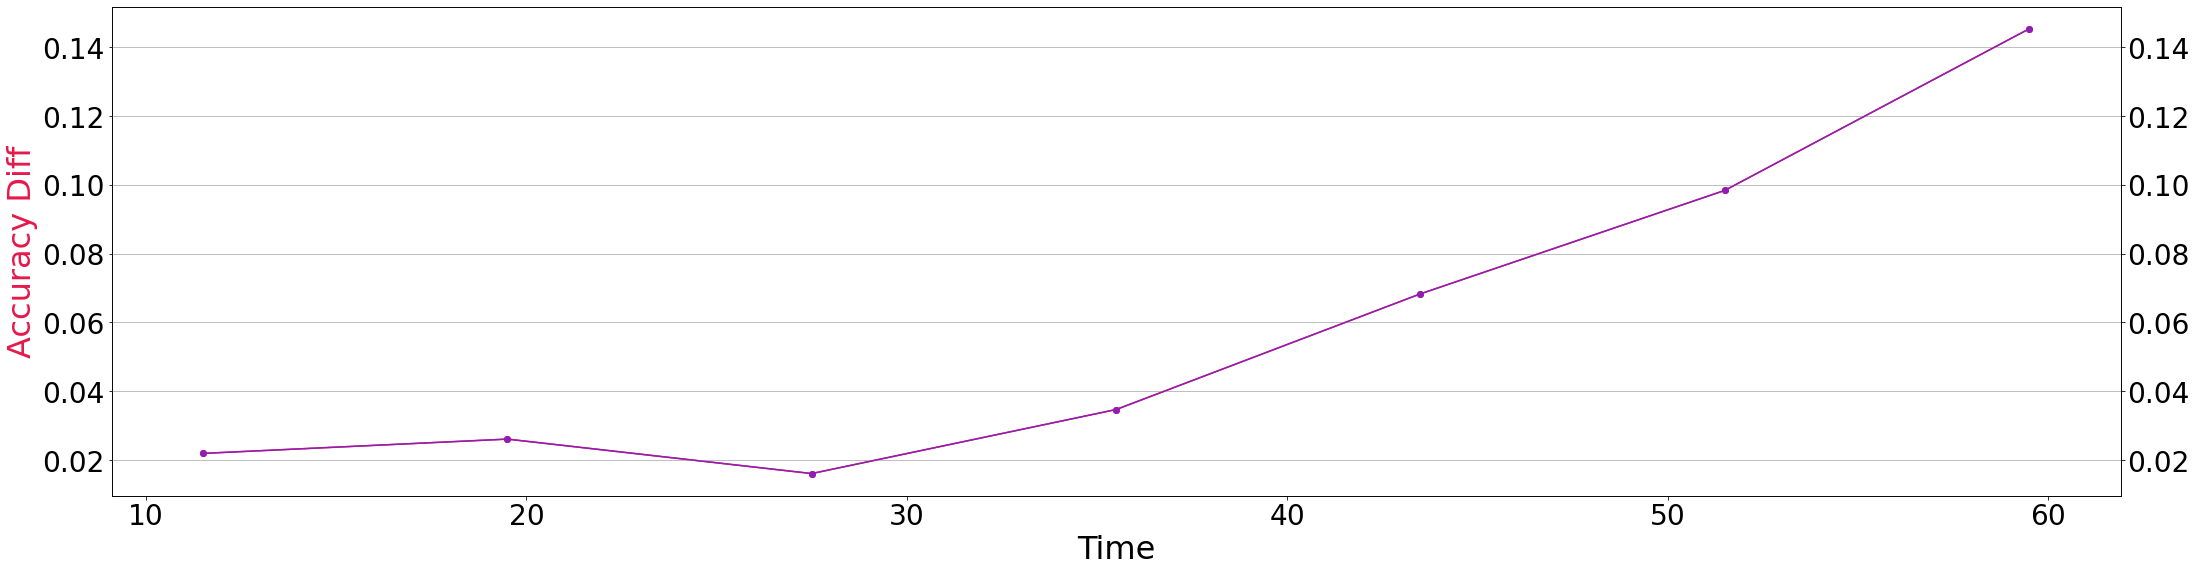

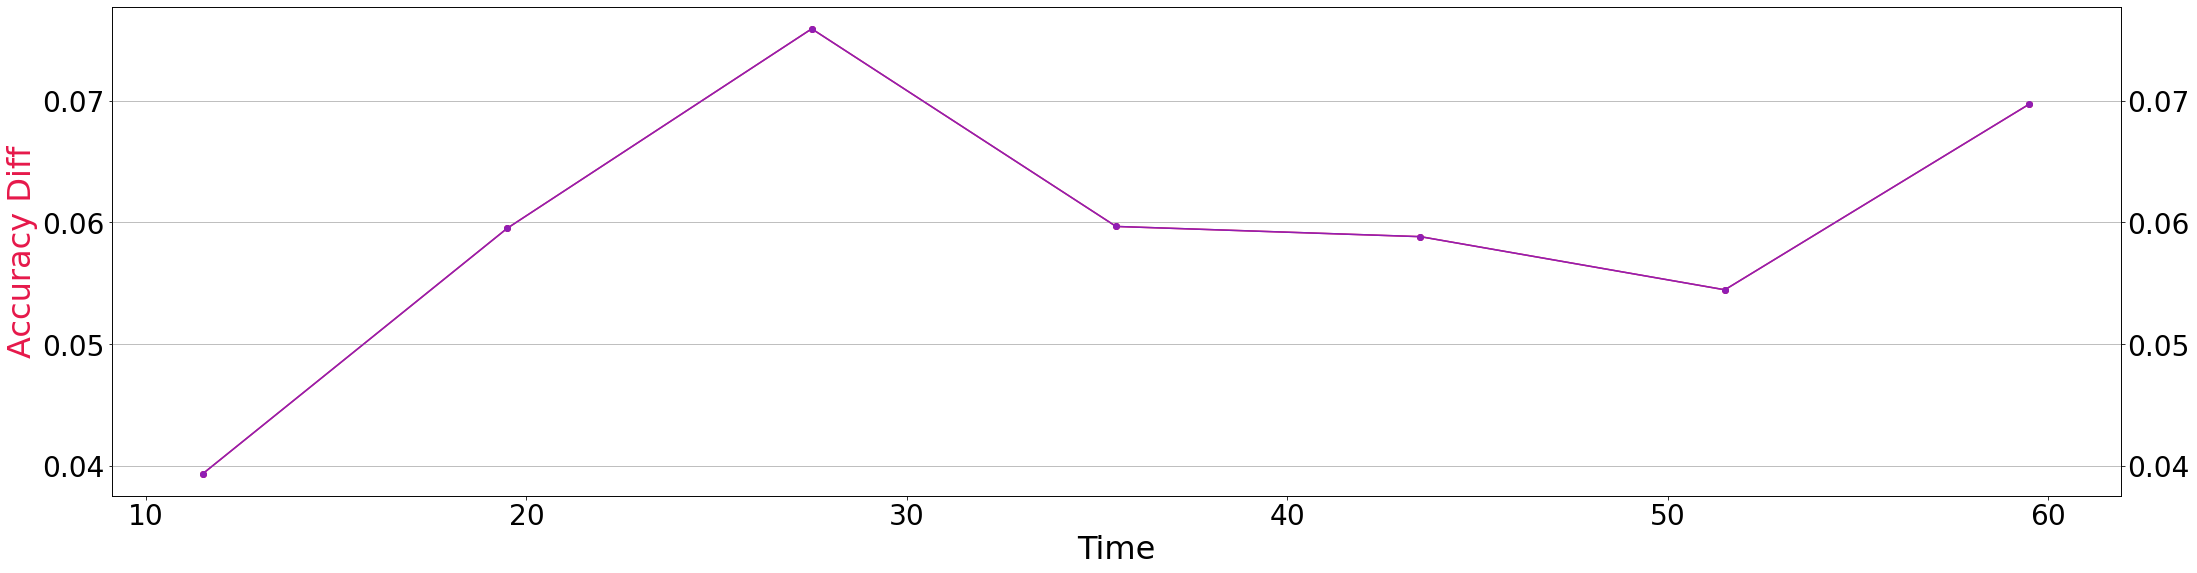

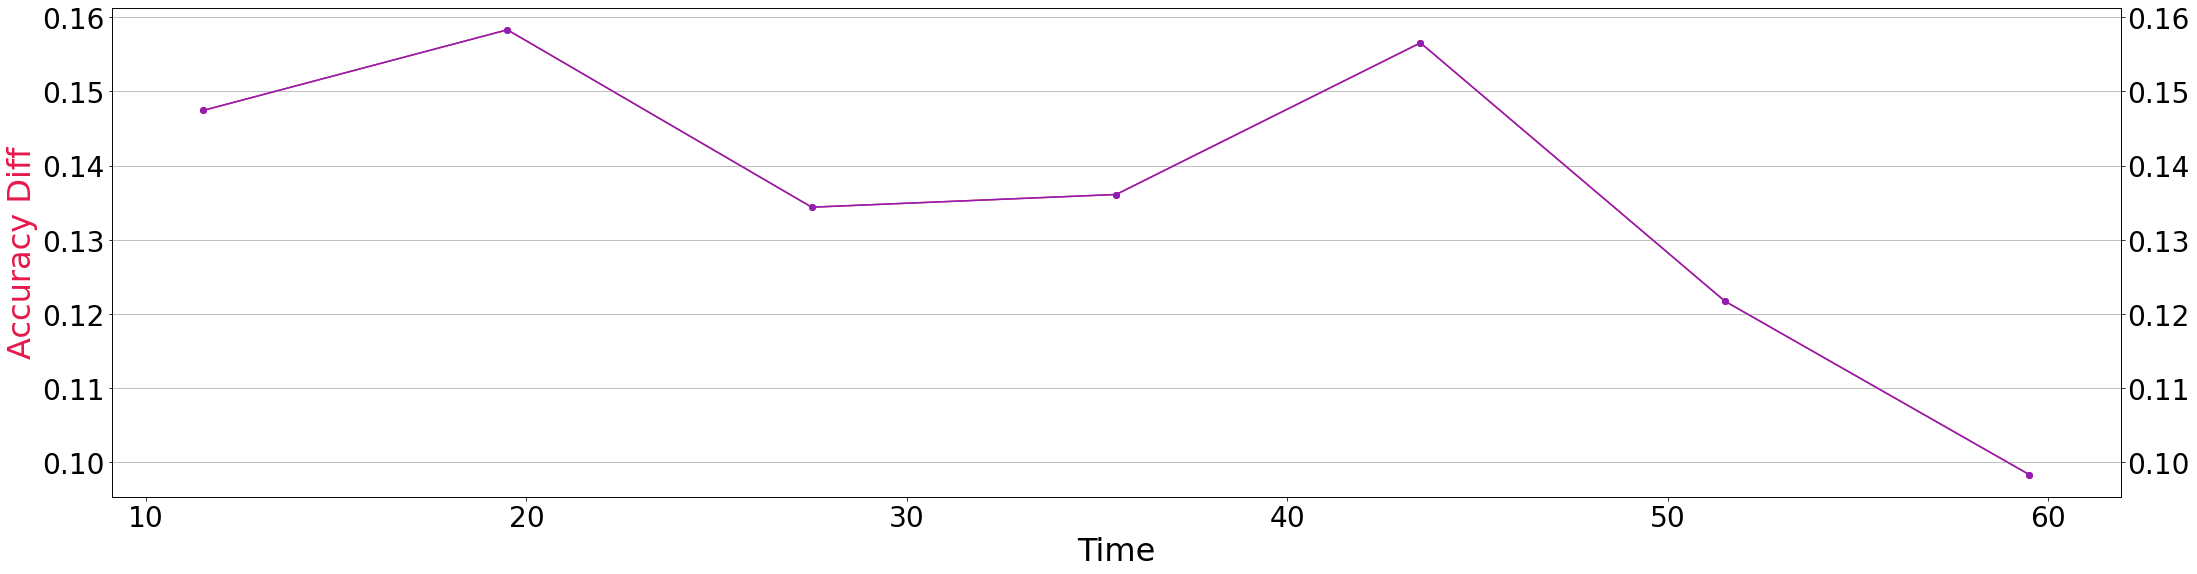

In [ ]:
for i in range(len(accuracy_result_dict_paths)):
	result_list = combined_result_dataset[i]
	combined_result_list = combine_average(result_list, result_interval)
	
	time_list = list(range(RP_AMOUNT, len(result_list) + RP_AMOUNT))
	combined_time_list = combine_average(time_list, result_interval)

	plot_two_ys(combined_time_list, combined_result_list, combined_result_list, 'Time', 'Accuracy Diff', '', f'')